# TP 2 – Visualisation des attaques de sécurité
### Dataset : TP_12.csv
Ce notebook répond aux **11 questions** du TP en utilisant pandas, matplotlib et seaborn.

---
## 📦 Import des bibliothèques

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Configuration globale
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('✅ Bibliothèques importées avec succès.')

✅ Bibliothèques importées avec succès.


---
## 📂 Chargement des données

In [2]:
df = pd.read_csv(r'c:\Users\MYC\Desktop\DATA science\TP1\TP_12.csv')

# Conversion Timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Colonnes dérivées
df['Hour']    = df['Timestamp'].dt.hour
df['Day']     = df['Timestamp'].dt.date
df['DayStr']  = df['Timestamp'].dt.strftime('%Y-%m-%d')
df['DayName'] = df['Timestamp'].dt.day_name()

print(f'✅ Données chargées : {df.shape[0]} lignes, {df.shape[1]} colonnes')

✅ Données chargées : 500 lignes, 9 colonnes


---
## ❓ Question 1 – Afficher les 10 premières lignes

In [3]:
df.head(10)

,Timestamp,SourceIP,AttackType,TargetIP,AttackDurationHours,Hour,Day,DayStr,DayName
0,2023-01-04 02:00:00,101.237.18.135,DDoS,56.151.20.145,6.545913,2,2023-01-04,2023-01-04,Wednesday
1,2023-01-02 05:00:00,13.2.114.130,Malware,239.110.38.24,19.305501,5,2023-01-02,2023-01-02,Monday
2,2023-01-02 18:00:00,152.233.21.95,Phishing,16.44.123.143,14.675355,18,2023-01-02,2023-01-02,Monday
3,2023-01-01 01:00:00,171.82.89.172,Malware,237.57.225.215,11.492876,1,2023-01-01,2023-01-01,Sunday
4,2023-01-02 07:00:00,75.135.27.7,Phishing,43.81.255.79,21.218443,7,2023-01-02,2023-01-02,Monday
5,2023-01-02 09:00:00,115.132.75.69,Phishing,34.103.20.105,9.047682,9,2023-01-02,2023-01-02,Monday
6,2023-01-03 05:00:00,99.69.4.133,DDoS,181.168.237.231,1.009749,5,2023-01-03,2023-01-03,Tuesday
7,2023-01-03 11:00:00,14.182.42.116,Malware,80.196.169.12,13.190158,11,2023-01-03,2023-01-03,Tuesday
8,2023-01-02 04:00:00,251.11.7.167,DDoS,45.220.66.66,15.953732,4,2023-01-02,2023-01-02,Monday
9,2023-01-04 16:00:00,136.88.238.253,Phishing,13.237.239.165,12.347218,16,2023-01-04,2023-01-04,Wednesday


---
## ❓ Question 2 – Décrire les colonnes et leurs types

In [4]:
print('=== Types des colonnes ===')
print(df.dtypes)
print('\n=== Informations générales ===')
df.info()
print('\n=== Statistiques descriptives (colonnes numériques) ===')
df.describe()

=== Types des colonnes ===
Timestamp              datetime64[ns]
SourceIP                       object
AttackType                     object
TargetIP                       object
AttackDurationHours           float64
Hour                            int32
Day                            object
DayStr                         object
DayName                        object
dtype: object

=== Informations générales ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Timestamp            500 non-null    datetime64[ns]
 1   SourceIP             500 non-null    object        
 2   AttackType           500 non-null    object        
 3   TargetIP             500 non-null    object        
 4   AttackDurationHours  500 non-null    float64       
 5   Hour                 500 non-null    int32         
 6   Day                 

,Timestamp,AttackDurationHours,Hour
count,500,500.000000,500.000000
mean,2023-01-03 01:45:36,11.870792,11.744000
min,2023-01-01 00:00:00,0.542774,0.000000
25%,2023-01-02 02:45:00,5.989240,6.000000
50%,2023-01-03 02:00:00,11.472929,12.000000
75%,2023-01-04 03:00:00,17.953547,18.000000
max,2023-01-05 03:00:00,23.996590,23.000000
std,NaN,6.749402,6.953788


---
## ❓ Question 3 – Séparer variables numériques et catégorielles

In [5]:
# Variables numériques
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Variables catégorielles (object + datetime)
cat_cols = df.select_dtypes(include=['object', 'datetime64[ns]']).columns.tolist()

print(f'📊 Variables NUMÉRIQUES ({len(num_cols)}) :')
for c in num_cols:
    print(f'   - {c}')

print(f'\n🔤 Variables CATÉGORIELLES ({len(cat_cols)}) :')
for c in cat_cols:
    print(f'   - {c}')

print(f'\n✅ Nombre total de variables numériques   : {len(num_cols)}')
print(f'✅ Nombre total de variables catégorielles : {len(cat_cols)}')

📊 Variables NUMÉRIQUES (2) :
   - AttackDurationHours
   - Hour

🔤 Variables CATÉGORIELLES (7) :
   - Timestamp
   - SourceIP
   - AttackType
   - TargetIP
   - Day
   - DayStr
   - DayName

✅ Nombre total de variables numériques   : 2
✅ Nombre total de variables catégorielles : 7


---
## ❓ Question 4 – Diagramme à barres : répartition des types d'attaques

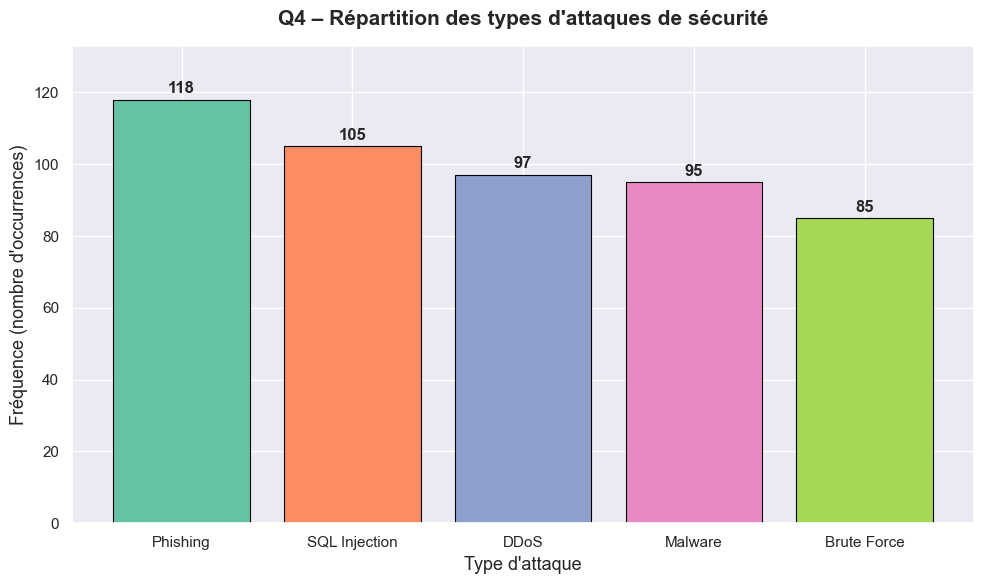

In [6]:
attack_counts = df['AttackType'].value_counts().reset_index()
attack_counts.columns = ['AttackType', 'Count']

palette = sns.color_palette('Set2', len(attack_counts))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(attack_counts['AttackType'], attack_counts['Count'],
              color=palette, edgecolor='black', linewidth=0.8)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title("Q4 – Répartition des types d'attaques de sécurité",
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Type d'attaque", fontsize=13)
ax.set_ylabel("Fréquence (nombre d'occurrences)", fontsize=13)
ax.set_ylim(0, attack_counts['Count'].max() + 15)
plt.xticks(fontsize=11)
plt.tight_layout()
plt.show()

---
## ❓ Question 5 – Fréquence des attaques par heure

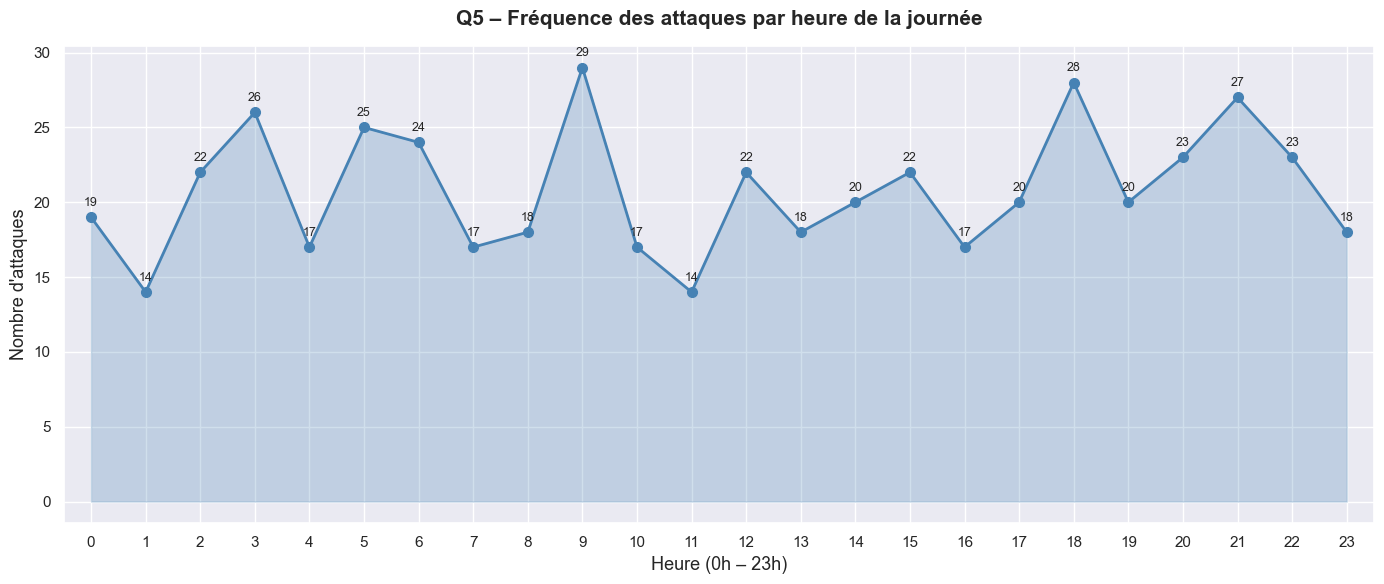

In [7]:
hourly_counts = df['Hour'].value_counts().sort_index().reset_index()
hourly_counts.columns = ['Hour', 'Count']

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(hourly_counts['Hour'], hourly_counts['Count'],
        marker='o', color='steelblue', linewidth=2, markersize=7)
ax.fill_between(hourly_counts['Hour'], hourly_counts['Count'],
                alpha=0.25, color='steelblue')

for _, row in hourly_counts.iterrows():
    ax.annotate(str(int(row['Count'])),
                xy=(row['Hour'], row['Count']),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=9)

ax.set_title('Q5 – Fréquence des attaques par heure de la journée',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Heure (0h – 23h)', fontsize=13)
ax.set_ylabel("Nombre d'attaques", fontsize=13)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.set_xlim(-0.5, 23.5)
plt.tight_layout()
plt.show()

---
## ❓ Question 6 – Diagramme à barres : fréquence des attaques par jour

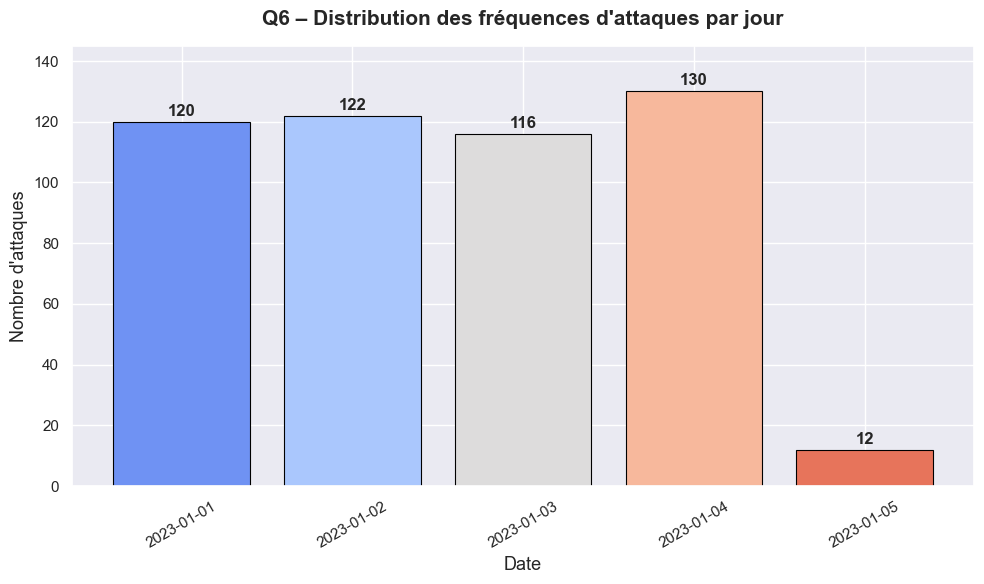

In [8]:
daily_counts = df.groupby('DayStr').size().reset_index(name='Count')

palette6 = sns.color_palette('coolwarm', len(daily_counts))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(daily_counts['DayStr'], daily_counts['Count'],
              color=palette6, edgecolor='black', linewidth=0.8)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title("Q6 – Distribution des fréquences d'attaques par jour",
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel("Nombre d'attaques", fontsize=13)
ax.set_ylim(0, daily_counts['Count'].max() + 15)
plt.xticks(rotation=30, fontsize=11)
plt.tight_layout()
plt.show()

---
## ❓ Question 7 – Diagramme circulaire : types d'attaques du 05/01/2023

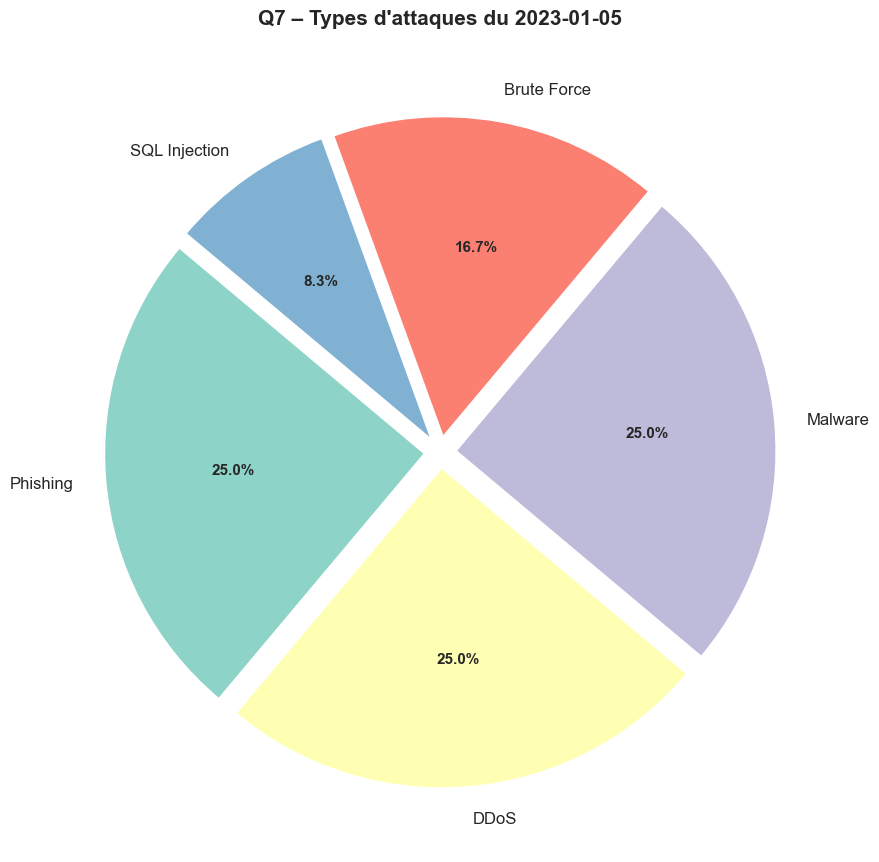

Nombre d'attaques le 2023-01-05 : 12


In [9]:
target_date = '2023-01-05'
df_day = df[df['DayStr'] == target_date]

if df_day.empty:
    print(f'Aucune attaque trouvée pour le {target_date}')
else:
    attack_day = df_day['AttackType'].value_counts()

    colors7  = sns.color_palette('Set3', len(attack_day))
    explode7 = [0.05] * len(attack_day)

    fig, ax = plt.subplots(figsize=(9, 9))
    wedges, texts, autotexts = ax.pie(
        attack_day.values,
        labels=attack_day.index,
        autopct='%1.1f%%',
        colors=colors7,
        explode=explode7,
        startangle=140,
        textprops={'fontsize': 12}
    )
    for at in autotexts:
        at.set_fontsize(11)
        at.set_fontweight('bold')

    ax.set_title(f"Q7 – Types d'attaques du {target_date}",
                 fontsize=15, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    print(f'Nombre d\'attaques le {target_date} : {len(df_day)}')

---
## ❓ Question 8 – Heatmap : fréquence des attaques par heure

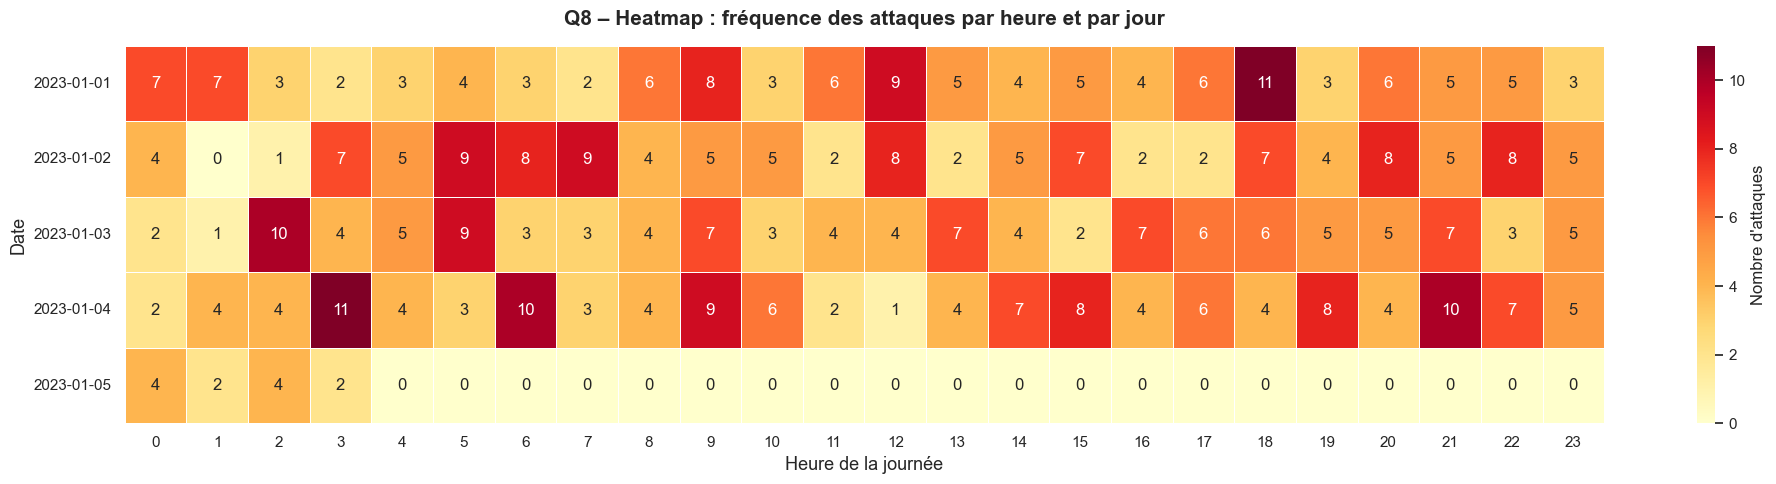

In [10]:
heatmap_data = df.groupby(['DayStr', 'Hour']).size().reset_index(name='Count')
heatmap_pivot = heatmap_data.pivot(index='DayStr', columns='Hour', values='Count').fillna(0)

fig, ax = plt.subplots(figsize=(20, 5))
sns.heatmap(
    heatmap_pivot,
    cmap='YlOrRd',
    linewidths=0.5,
    annot=True,
    fmt='.0f',
    ax=ax,
    cbar_kws={'label': "Nombre d'attaques"}
)
ax.set_title('Q8 – Heatmap : fréquence des attaques par heure et par jour',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Heure de la journée', fontsize=13)
ax.set_ylabel('Date', fontsize=13)
plt.tight_layout()
plt.show()

---
## ❓ Question 9 – Diagramme circulaire : sources d'attaques (Top 10)

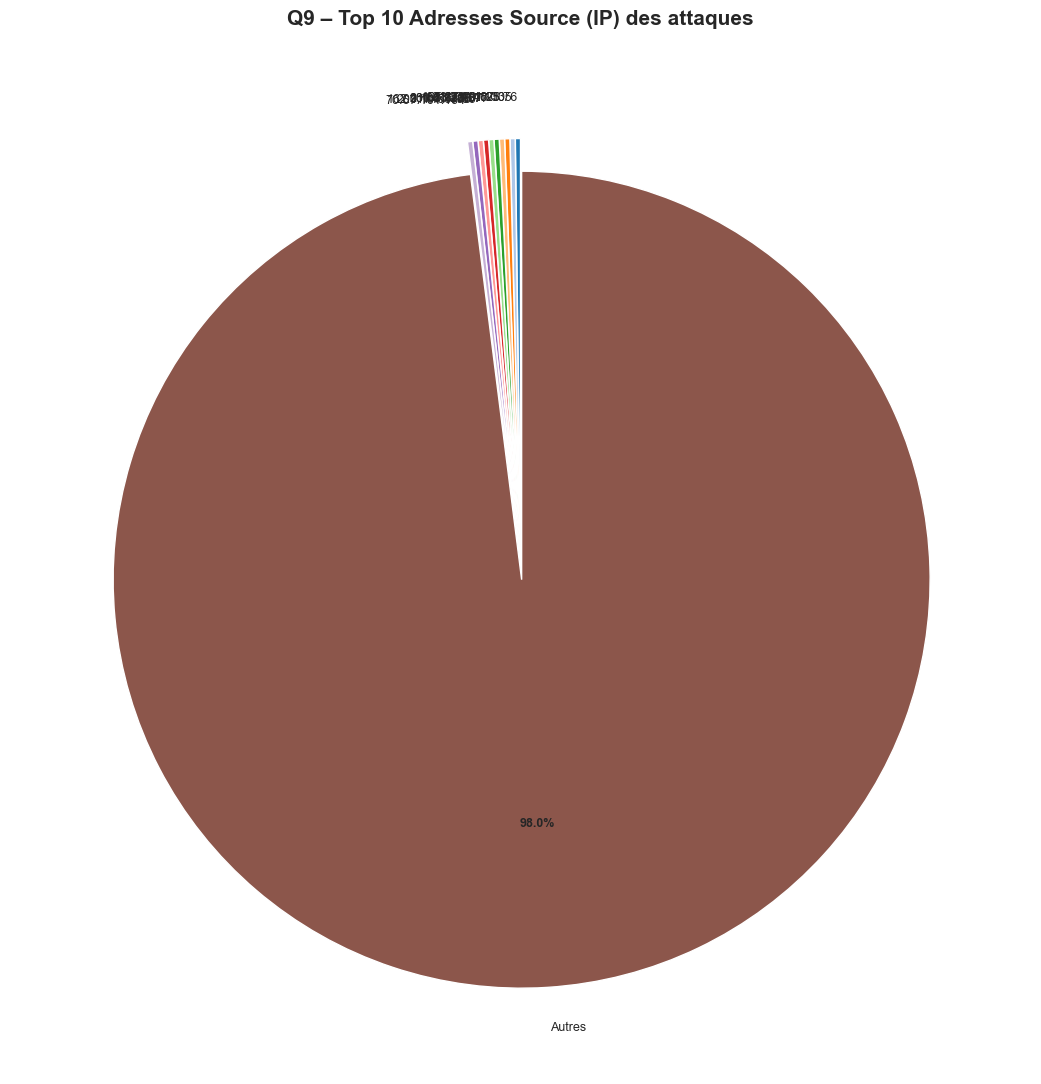


Nombre total d'adresses IP sources uniques : 500


In [11]:
top_n = 10
source_counts = df['SourceIP'].value_counts()
top_sources   = source_counts.head(top_n)
other_sources = source_counts.iloc[top_n:].sum()

labels9 = list(top_sources.index) + ['Autres']
sizes9  = list(top_sources.values) + [other_sources]

colors9  = sns.color_palette('tab20', len(labels9))
explode9 = [0.04] * len(labels9)

fig, ax = plt.subplots(figsize=(11, 11))
wedges, texts, autotexts = ax.pie(
    sizes9,
    labels=labels9,
    autopct=lambda p: f'{p:.1f}%' if p > 1 else '',
    colors=colors9,
    explode=explode9,
    startangle=90,
    textprops={'fontsize': 9}
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')

ax.set_title(f'Q9 – Top {top_n} Adresses Source (IP) des attaques',
             fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(f"\nNombre total d'adresses IP sources uniques : {len(source_counts)}")

---
## ❓ Question 10 – Diagramme circulaire : cibles d'attaques (Top 10)

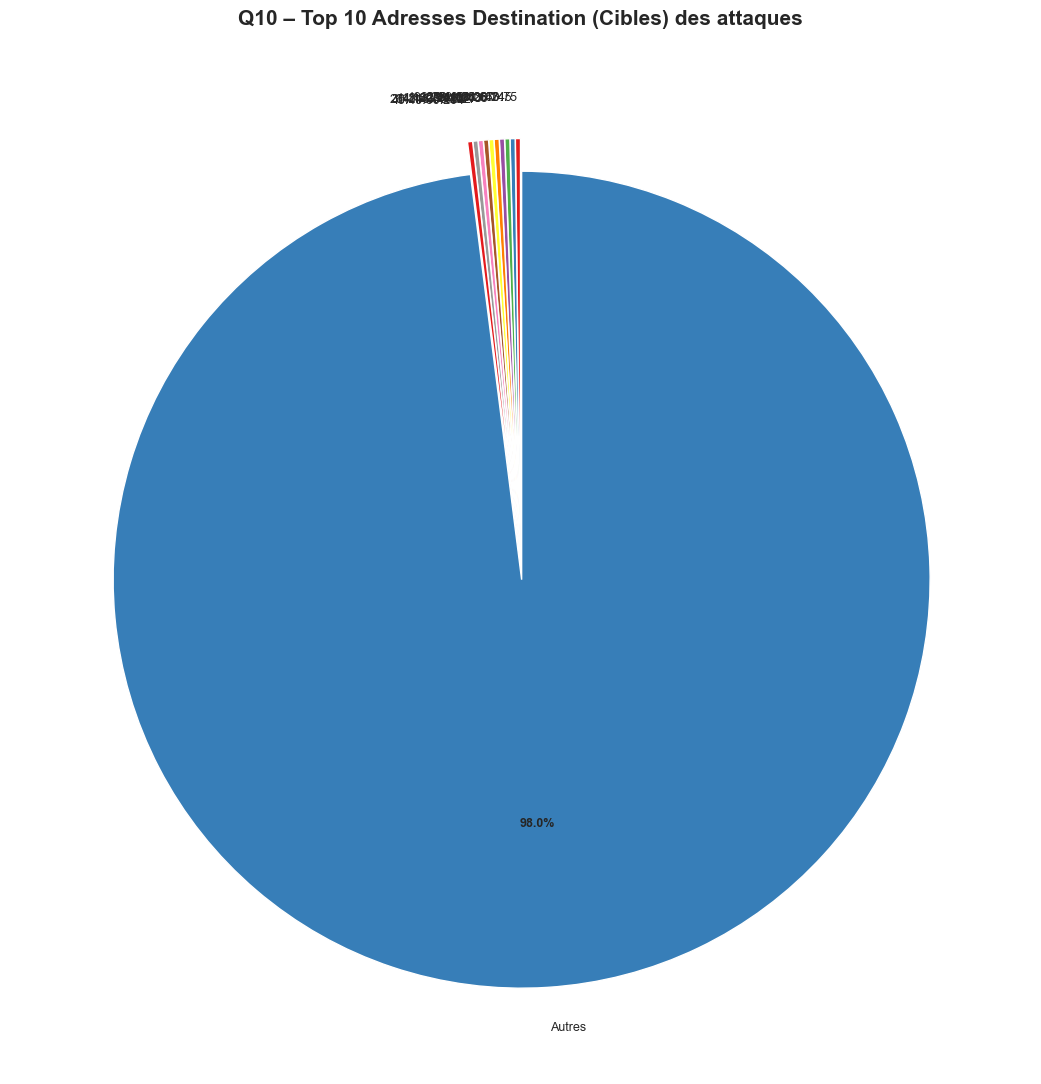


Nombre total d'adresses IP cibles uniques : 500


In [12]:
target_counts = df['TargetIP'].value_counts()
top_targets   = target_counts.head(top_n)
other_targets = target_counts.iloc[top_n:].sum()

labels10 = list(top_targets.index) + ['Autres']
sizes10  = list(top_targets.values) + [other_targets]

colors10  = sns.color_palette('Set1', len(labels10))
explode10 = [0.04] * len(labels10)

fig, ax = plt.subplots(figsize=(11, 11))
wedges, texts, autotexts = ax.pie(
    sizes10,
    labels=labels10,
    autopct=lambda p: f'{p:.1f}%' if p > 1 else '',
    colors=colors10,
    explode=explode10,
    startangle=90,
    textprops={'fontsize': 9}
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')

ax.set_title(f'Q10 – Top {top_n} Adresses Destination (Cibles) des attaques',
             fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(f"\nNombre total d'adresses IP cibles uniques : {len(target_counts)}")

---
## ❓ Question 11 – Boxplots : distribution des durées par type d'attaque

C:\Users\MYC\AppData\Local\Temp\ipykernel_12552\1670414595.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


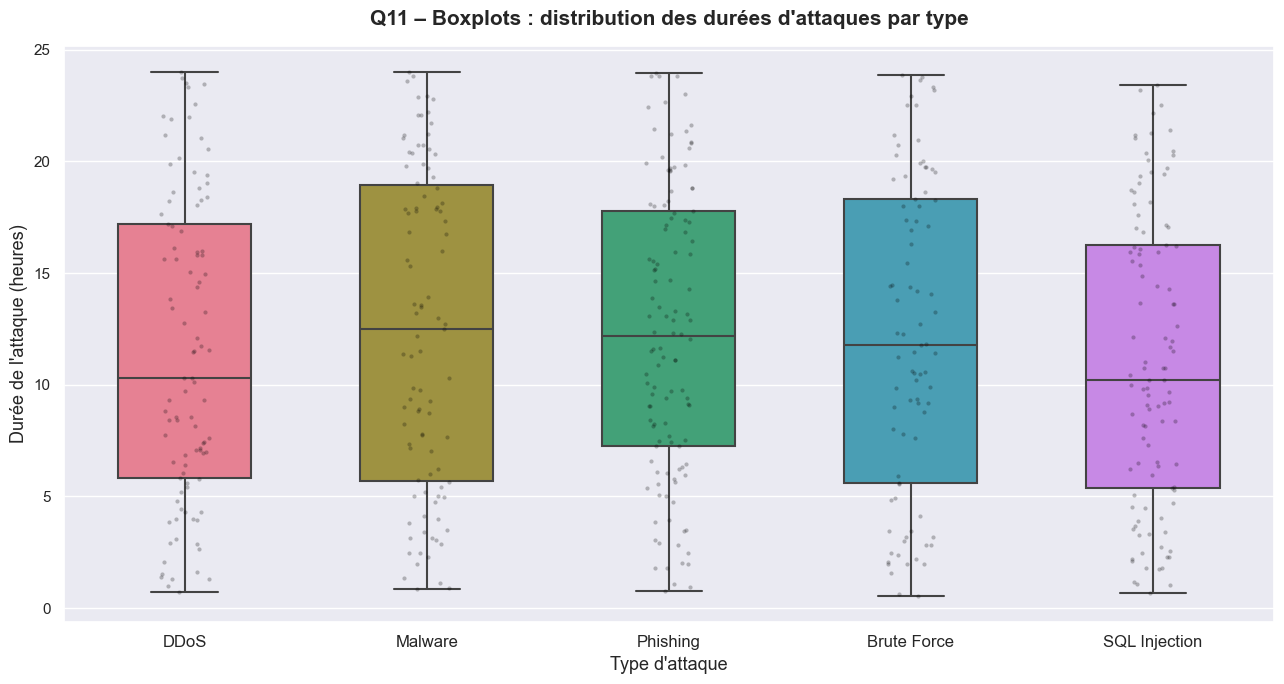


Statistiques des durées par type d'attaque :


,count,mean,std,min,25%,50%,75%,max
AttackType,,,,,,,,
Brute Force,85.0,12.15,7.03,0.54,5.58,11.78,18.33,23.85
DDoS,97.0,11.48,6.80,0.74,5.84,10.30,17.21,24.00
Malware,95.0,12.40,7.13,0.84,5.70,12.48,18.92,23.99
Phishing,118.0,12.28,6.41,0.77,7.25,12.17,17.76,23.95
SQL Injection,105.0,11.07,6.51,0.70,5.39,10.21,16.26,23.41


In [13]:
attack_types = df['AttackType'].unique()
palette11 = dict(zip(attack_types, sns.color_palette('husl', len(attack_types))))

fig, ax = plt.subplots(figsize=(13, 7))
sns.boxplot(
    data=df,
    x='AttackType',
    y='AttackDurationHours',
    palette=palette11,
    width=0.55,
    linewidth=1.5,
    flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.6),
    ax=ax
)
sns.stripplot(
    data=df,
    x='AttackType',
    y='AttackDurationHours',
    color='black',
    alpha=0.25,
    size=3,
    jitter=True,
    ax=ax
)

ax.set_title("Q11 – Boxplots : distribution des durées d'attaques par type",
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Type d'attaque", fontsize=13)
ax.set_ylabel("Durée de l'attaque (heures)", fontsize=13)
plt.xticks(fontsize=12)
plt.tight_layout()
plt.show()

print("\nStatistiques des durées par type d'attaque :")
df.groupby('AttackType')['AttackDurationHours'].describe().round(2)